In [1]:
#importing  necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
# setting data types beforehand to reduce memory consumption
taxis_dtypes = {
    "passengers":"category",
    "color":"category",
    "payment":"category",
    "pickup_borough":"category",
    "dropoff_borough":"category"
}

In [3]:
#importing taxis data and parsing date columns 
taxis_data = pd.read_csv("taxis.csv", dtype = taxis_dtypes, parse_dates = ["pickup","dropoff"])

In [4]:
#previewing the data
taxis_data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
#checking for the size of the dataset
len(taxis_data)

6433

In [6]:
#inspecting the data
taxis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   category      
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   category      
 9   payment          6389 non-null   category      
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   category      
 13  dropoff_borough  6388 non-null   category      
dtypes: category(5), datetime64[ns](2), float

In [7]:
#previewing the descriptive statistcs of all categorical variables
taxis_data.describe(include = ["category"])

,passengers,color,payment,pickup_borough,dropoff_borough
count,6433,6433,6389,6407,6388
unique,7,2,2,4,5
top,1,yellow,credit card,Manhattan,Manhattan
freq,4678,5451,4577,5268,5206


In [8]:
#previewing descriptive statistics of all numeric variables
taxis_data.describe(include = ["number"])

,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,3.024617,13.091073,1.97922,0.325273,18.517794
std,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,1.000000,0.00000,0.000000,1.300000
25%,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.640000,9.500000,1.70000,0.000000,14.160000
75%,3.210000,15.000000,2.80000,0.000000,20.300000
max,36.700000,150.000000,33.20000,24.020000,174.820000


In [9]:
#checking for duplicates
taxis_data[taxis_data.duplicated(subset = ["pickup", "dropoff", "passengers","fare"], keep = False)]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough


In [10]:
#checking for null values
taxis_data.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [11]:
#threshold for dropping missing/null values
threshold = len(taxis_data)* 0.05


In [12]:
#identifying columns with a number of missing values below or equal to a certain threshold(5% of the dataset)
cols_with_missing_values_to_drop = taxis_data.columns[(taxis_data.isnull().sum() <= threshold) & (taxis_data.isnull().sum() != 0)]
cols_with_missing_values_to_drop

Index(['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')

In [13]:
#dropping indexes of cols with missing values less than 5% of the dataset
taxis_data.dropna(subset = cols_with_missing_values_to_drop, inplace = True)

In [14]:
#checking for outliers
Q1 = taxis_data["distance"].quantile(0.25)
Q3 = taxis_data["distance"].quantile(0.75)
iqr = Q3 - Q1
lower_threshold = Q1 - 1.5*iqr
upper_threshold = Q3 + 1.5*iqr
outliers = taxis_data[(taxis_data["distance"] < lower_threshold) | (taxis_data["distance"] > upper_threshold)]

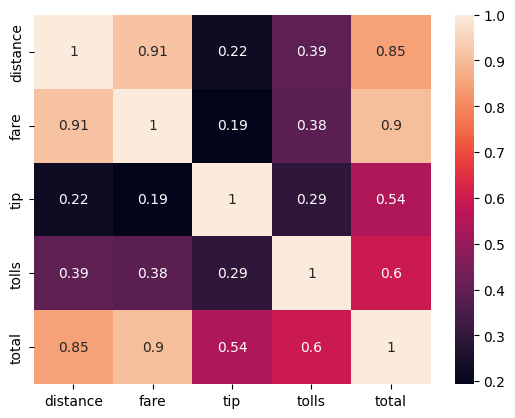

In [15]:
sns.heatmap(outliers.corr(numeric_only = True, method = "pearson"), annot = True )
#plt.savefig("outputs/outliers_heatmap.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [16]:
outliers.groupby(["pickup_borough","dropoff_borough"], observed = True).size()

pickup_borough  dropoff_borough
Bronx           Bronx                6
                Brooklyn             3
                Manhattan           17
                Queens               4
Brooklyn        Bronx                5
                Brooklyn            21
                Manhattan           25
                Queens              21
Manhattan       Bronx               28
                Brooklyn            62
                Manhattan           95
                Queens             117
                Staten Island        2
Queens          Bronx               10
                Brooklyn            60
                Manhattan          196
                Queens              46
dtype: int64

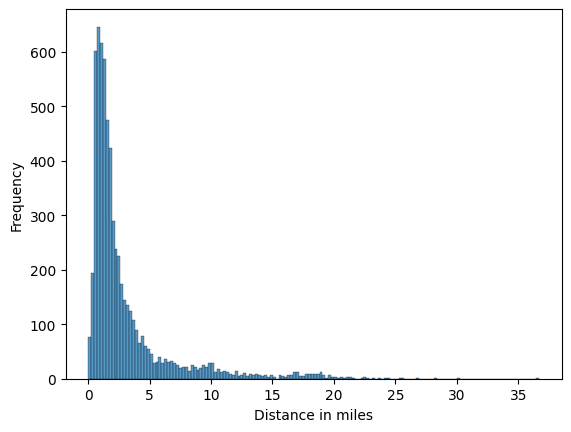

In [17]:
#getting sense of the distribution of distance in the dataset
g = sns.histplot(data = taxis_data, x = "distance")
g.set(xlabel = "Distance in miles",
     ylabel = "Frequency")
#plt.savefig("outputs/distance_distribution.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [18]:
#handling outliers by keeping only trips less or equal to 15 miles
clean_taxis_data = taxis_data[taxis_data["distance"] <= 15].copy()

In [19]:
#checking the impact of outliers
#taxis_data with outliers - checking the mean distance
taxis_data[["distance"]].mean()

distance    2.997707
dtype: float64

In [20]:
#checking the impact of outliers

#clean_taxis_data with no outliers - checking the mean distance
clean_taxis_data[["distance"]].mean()

distance    2.554222
dtype: float64

In [21]:
#outliers to be analysed 
long_trips = taxis_data[taxis_data["distance"] > 15]
#saving the dataframe in a csv file
long_trips.to_csv("long_trips.csv")

In [22]:
#cross-field validation
sum_of_cols = clean_taxis_data[["fare","tip","tolls"]].sum(axis = 1)

In [23]:
#consistency-check
is_equal = sum_of_cols == clean_taxis_data["total"]
consistent_sums = clean_taxis_data[is_equal]
consistent_sums.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
5525,2019-03-11 11:51:57,2019-03-11 11:57:23,1,0.92,5.0,0.0,0.0,5.0,green,cash,Astoria,Queensbridge/Ravenswood,Queens,Queens
5584,2019-03-05 14:18:39,2019-03-05 14:30:34,2,5.94,35.0,0.0,0.0,35.0,green,credit card,East Harlem North,LaGuardia Airport,Manhattan,Queens
5691,2019-03-20 12:32:56,2019-03-20 12:40:25,1,2.48,12.0,0.0,0.0,12.0,green,credit card,Jamaica Estates,Flushing Meadows-Corona Park,Queens,Queens
5705,2019-03-16 22:06:05,2019-03-16 22:17:20,1,5.01,12.0,0.0,0.0,12.0,green,cash,Mott Haven/Port Morris,Soundview/Castle Hill,Bronx,Bronx
5742,2019-03-27 12:31:51,2019-03-27 12:43:55,1,1.68,8.0,0.0,0.0,8.0,green,cash,East Concourse/Concourse Village,Melrose South,Bronx,Bronx


In [24]:
#inconsistency-check
inconsistent_sums = clean_taxis_data[~is_equal]
inconsistent_sums.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [25]:
#creating the surcharges column to make the numerical columns consistent
clean_taxis_data["surcharges"] = clean_taxis_data["total"] -(clean_taxis_data[["fare","tip","tolls"]].sum(axis = 1))

In [26]:
#creating hour, day, trip_duration and total_earnings columns
clean_taxis_data["hour"] = clean_taxis_data["pickup"].dt.hour

clean_taxis_data["day"] = clean_taxis_data["pickup"].dt.day_name()

clean_taxis_data["trip_duration"] = (clean_taxis_data["dropoff"]-clean_taxis_data["pickup"]).dt.total_seconds()/60

clean_taxis_data["total_earnings"] = clean_taxis_data["fare"] +  clean_taxis_data["tip"] 

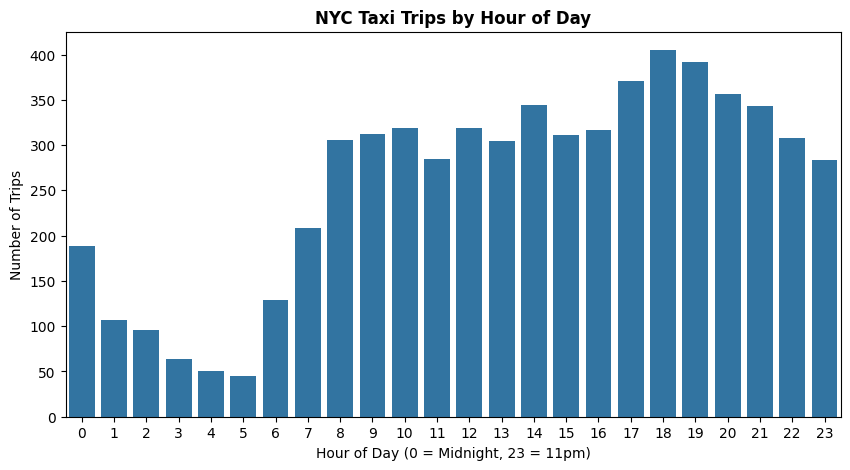

In [27]:
#plotting trips by hour to show peak demand times
hourly_trips = clean_taxis_data["hour"].value_counts().sort_index()

plt.figure(figsize = (10,5))

g = sns.barplot(x = hourly_trips.index, y = hourly_trips.values)

g.set(xlabel = "Hour of Day (0 = Midnight, 23 = 11pm)",
     ylabel = "Number of Trips")

plt.title("NYC Taxi Trips by Hour of Day", weight = "bold")

#plt.savefig("outputs/trip_volume_by_hour.png", dpi = 300, bbox_inches = "tight")

plt.show()

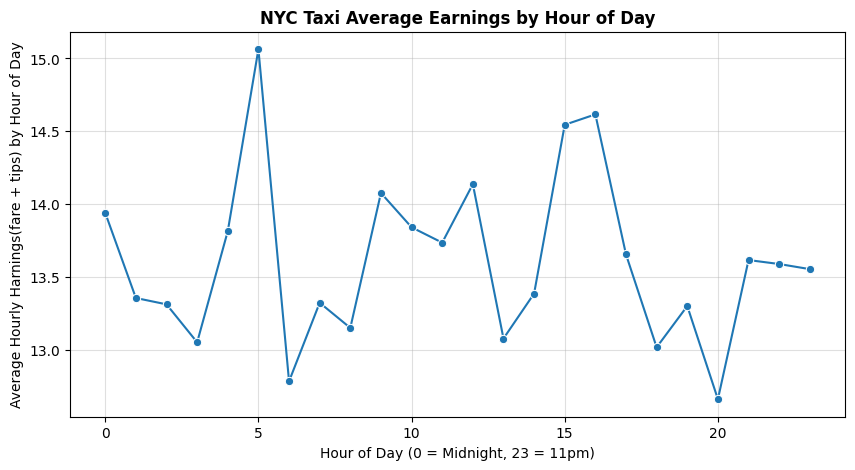

In [28]:
#groupng by hour to see the total_earnings per hour
hourly_earnings = clean_taxis_data.groupby("hour")["total_earnings"].mean()

#plotting to show total earnings per each hour
plt.figure(figsize = (10,5))

g = sns.lineplot(x = hourly_earnings.index, y = hourly_earnings.values, marker = "o")

g.set(xlabel = "Hour of Day (0 = Midnight, 23 = 11pm)",
     ylabel = "Average Hourly Harnings(fare + tips) by Hour of Day")

plt.title("NYC Taxi Average Earnings by Hour of Day", weight = "bold")

plt.grid(alpha = 0.4)

#plt.savefig("outputs/average_earnings_per_hour.png", dpi = 300, bbox_inches = "tight")

plt.show()

In [29]:
#creating days_order variable to be assigned to the order parameter of seaborn's catplot to make the days in the plot appear in order
days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

In [30]:
#discovering the pickup per each day of the week
daily_trips = clean_taxis_data["day"].value_counts()

<Figure size 1000x500 with 0 Axes>

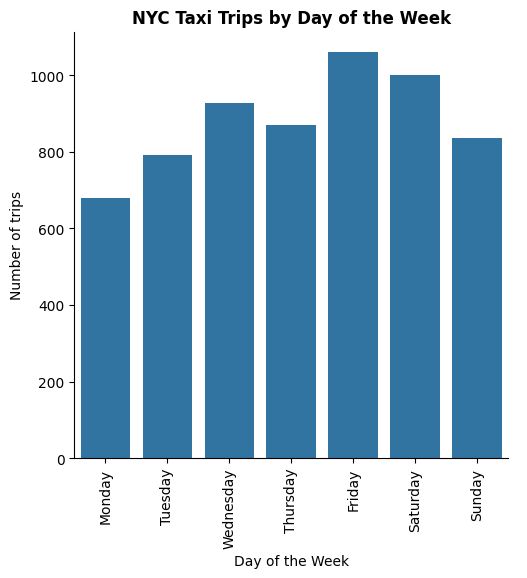

In [31]:
#plotting to show the pickup volume per each day
plt.figure(figsize = (10,5))

g = sns.catplot(x = daily_trips.index, y = daily_trips.values, kind = "bar", order = days_order)

g.set(xlabel = "Day of the Week",
     ylabel = "Number of trips")

plt.title("NYC Taxi Trips by Day of the Week", weight = "bold")

plt.xticks(rotation = 90)

#plt.savefig("outputs/trip_volume_by_day.png", dpi = 300, bbox_inches = "tight")

plt.show()

In [32]:
#getting all the zones in the dataset
zones = clean_taxis_data["pickup_zone"].value_counts()
#getting the top ten busiest zones
top_10_zones = zones.head(10)
print(top_10_zones)

pickup_zone
Midtown Center                  223
Penn Station/Madison Sq West    209
Upper East Side South           207
Clinton East                    207
Midtown East                    192
Upper East Side North           184
Times Sq/Theatre District       180
Union Sq                        178
Lincoln Square East             174
Murray Hill                     155
Name: count, dtype: int64


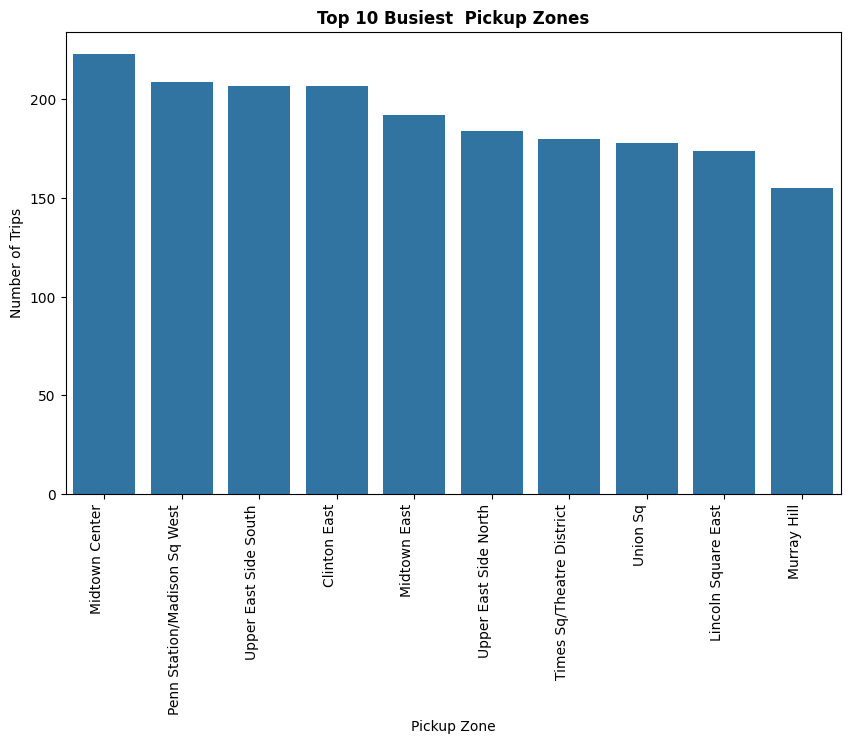

In [33]:
#plotting the top 10 busiest zones
plt.figure(figsize=(10,6))

sns.barplot(x = top_10_zones.index, y = top_10_zones.values)

plt.title("Top 10 Busiest  Pickup Zones", weight = "bold")

plt.xlabel("Pickup Zone")

plt.ylabel("Number of Trips")

plt.xticks(rotation = 90, ha = "right")

#plt.savefig("outputs/top_10_busiest_zones.png", dpi = 300, bbox_inches = "tight")

plt.show()

In [34]:
#etting the top five busiest zones 
top_5_zones = zones.head(5).index
#creating hourly_busy_zones by filtering the dataset to include only pickup zones in the top five
hourly_busy_zones = clean_taxis_data[clean_taxis_data["pickup_zone"].isin(top_5_zones)]
#grouping by hour and pickup_zones to see the number of pickups in each zone at each hour
hourly_busy_zones = hourly_busy_zones.groupby(["hour","pickup_zone"]).size().unstack(fill_value = 0)

In [35]:
hourly_busy_zones

pickup_zone,Clinton East,Midtown Center,Midtown East,Penn Station/Madison Sq West,Upper East Side South
hour,,,,,
0,11,6,4,3,2
1,2,3,3,4,2
2,7,2,3,2,0
3,5,2,1,2,0
4,4,1,1,2,0
5,2,0,0,2,1
6,12,1,2,5,2
7,3,4,4,14,8
8,12,5,5,11,9


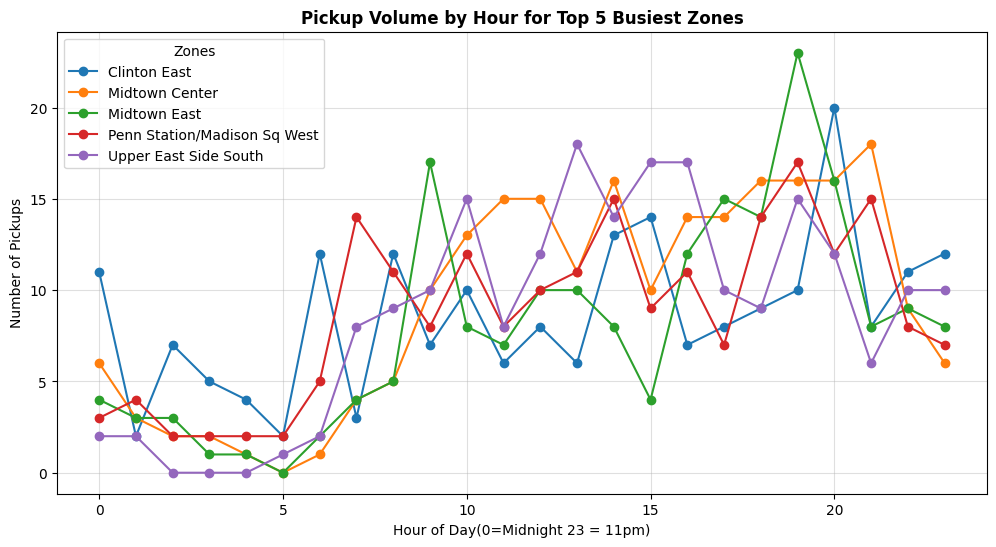

In [36]:
#plotting to show how busy each zone is at each hour
hourly_busy_zones.plot(kind = "line", marker = "o", figsize = (12,6))

plt.xlabel("Hour of Day(0=Midnight 23 = 11pm)")

plt.ylabel("Number of Pickups")

plt.title("Pickup Volume by Hour for Top 5 Busiest Zones", weight = "bold")

plt.legend(title = "Zones")

plt.grid(alpha = 0.4)

#plt.savefig("outputs/pickup_volume_by_hour_for_top_5.png", dpi = 300, bbox_inches = "tight")

plt.show()

In [37]:
#creating daily_busy_zones by including only the top five busiest zones
daily_busy_zones = clean_taxis_data[clean_taxis_data["pickup_zone"].isin(top_5_zones)]

#grouping by hour and pickup_zone to see the number of pickups in each zone at each day
daily_busy_zones = daily_busy_zones.groupby(["day","pickup_zone"]).size().unstack(fill_value = 0)

#reindexing the dataframe to make sure the days appear in their correct order
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_busy_zones = daily_busy_zones.reindex(day_order)

daily_busy_zones

pickup_zone,Clinton East,Midtown Center,Midtown East,Penn Station/Madison Sq West,Upper East Side South
day,,,,,
Monday,24,37,23,13,20
Tuesday,29,25,46,35,39
Wednesday,29,42,24,29,44
Thursday,27,40,23,31,26
Friday,37,42,38,33,26
Saturday,30,17,17,39,33
Sunday,31,20,21,29,19


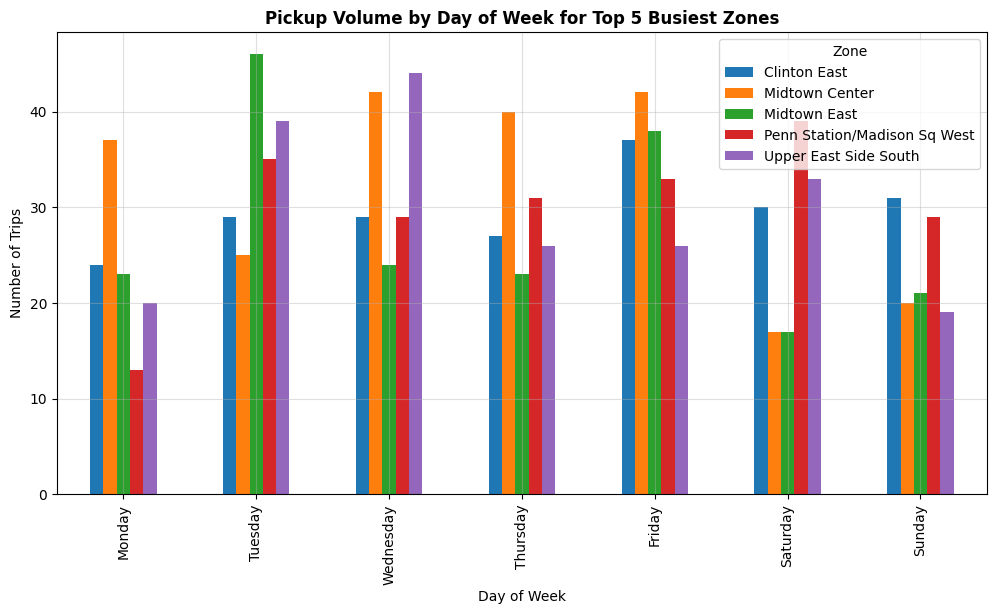

In [38]:
#plotting pickup volume by day in the top five busiest zones 
daily_busy_zones.plot(kind = "bar", figsize = (12,6))

plt.xlabel("Day of Week")

plt.ylabel("Number of Trips")

plt.title("Pickup Volume by Day of Week for Top 5 Busiest Zones", weight = "bold")

plt.legend(title = "Zone")

plt.grid(alpha = 0.4)

#plt.savefig("outputs/pickup_volume_by_day_for_top_5.png", dpi = 300, bbox_inches = "tight")

plt.show()